# ***Predicting Firm-Level Loss Behaviour and Corporate Income Tax (CIT) Revenue Risk in Kenya***


### Authors

Brian Kahiu, John Karanja, Cyrus Mutuku, Catherine Gachiri, Fredrick Nzeve, Grace Kinyanjui, Jeremy Onsongo


### 1.0 Business Understanding

### Background Information

The Kenya Revenue Authority (KRA), established in 1995, is responsible for collecting all national government revenue. Corporate Income Tax (CIT) is levied at 30% for resident companies and non-residents under the Income Tax Act, with sector-specific incentives available through Special Economic Zones (SEZs), Capital Deductions and Export Processing Zones (EPZs).

Companies must file annual CIT returns (ITC2 form) electronically via the iTax platform within six months of their accounting year-end, supported by valid electronic Tax Invoice Management System (eTIMS) invoices. Taxable income is calculated as gross income less allowable business expenses. A company is considered tax resident if incorporated in Kenya or if management and control is exercised locally.

### Business Problem Definition

Kenya has persistently failed to meet Corporate Income Tax (CIT) revenue targets. The high prevalence of firms reporting losses significantly erodes the effective tax base, creating fiscal deficit. The central problem is the lack of an empirical, data-driven framework for:

1. Identifying which firm-level characteristics are associated with loss reporting.
2. Proactively identifying high-risk firms and sectors.
3. Assessing how firm-level loss behavior translates into systemic CIT revenue risk.

### Our Solution

An automated risk scoring system that:

1. Processes firm-level CIT return data using the methodology outlined in the project proposal.
2. Employs an iterative modeling approach, beginning with interpretable logistic regression as a primary benchmark.
3. Applies machine learning to identify high-risk loss-reporting firms for targeted compliance.

### Project Objectives

***General Objective***

To predict the probability of a firm reporting a loss

***Specific Objectives***

1. To empirically identify firm-level characteristics associated with loss reporting in CIT returns.
2. To develop a supervised predictive model estimating the probability of a firm reporting a loss.
3. To assess the concentration and distribution of loss behavior across sectors and firm groups.
4. To translate firm-level loss probabilities into insights on aggregate CIT revenue risk.

### Methodology

This project follows the Cross-Industry Standard Process for Data Mining (CRISP-DM) to ensure a structured, transparent, and policy-relevant analytics workflow.

### Business Understanding

Stakeholder needs were identified, the business problem was defined, and success metrics were established to align analytical outputs with compliance and fiscal objectives.

### Data Understanding

Corporate Income Tax return data for 2024 were explored to assess structure and data quality.


### Primary Stakeholders

1. KRA Compliance Directors

***Problem:*** Manual audit selection misses high-risk loss-reporting firms

***Need:*** Prioritize firms with highest evasion probability for investigation

***Business Value:*** Improved audit efficiency and revenue recovery

2. Tax Policy Analysts at National Treasury

***Problem:*** Revenue forecasting uncertainty due to loss declaration patterns

***Need:*** Data-driven risk assessment for fiscal planning and budgeting

***Business Value:*** Improved accuracy in CIT revenue projections

3. Field Tax Officers

***Problem:*** Wasted time on low-risk audits with minimal revenue recovery

***Need:*** Focus investigations on firms with highest probability of tax avoidance

***Business Value:*** Higher productivity and improved targeting outcomes

### 2.0 Data Description
The analysis uses 2024 Corporate Income Tax return data containing 313,870 firm-year observations across 61 variables (47 numeric, 14 categorical). The dataset includes financial data, sector classifications, and firm characteristics from administrative filings.

### 3.0 Modeling Scope Definition

Validity: Retain only active businesses with positive turnover

Target: Flag firms as "Risk" (is_loss = 1) if Profit Before Tax is negative

Sector Standardization: Clean sector names and consolidate rare sectors




### 1.0 Import the necessary libraries

We import the key libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import xgboost as xgb

# Machine learning Preprocessing & Utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine learning Metrics
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_curve, precision_recall_curve, brier_score_loss, log_loss
)

# Model interpretability
import shap

# Model saving
import joblib

# System utilities
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


### 2.0 Data loading and Initial Checks
Here, we imported the raw tax data and examined its basic structure.

In [2]:
df = pd.read_csv("CIT2024.csv", low_memory=False)
df.shape

(313870, 61)

In [3]:
df.info()
print(df.dtypes.value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313870 entries, 0 to 313869
Data columns (total 61 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   unique_id                      313870 non-null  float64
 1   business_type                  313870 non-null  object 
 2   business_subtype               310874 non-null  object 
 3   epz_effective_dt               149 non-null     object 
 4   period_from                    313870 non-null  object 
 5   period_to                      313870 non-null  object 
 6   filing_date                    313870 non-null  object 
 7   is_nil_return                  313870 non-null  object 
 8   return_type                    313870 non-null  object 
 9   assmt_type                     313870 non-null  object 
 10  eff_dt_com_activity            85 non-null      object 
 11  sector                         313862 non-null  object 
 12  division_                     

In [4]:
df.head(5)

,unique_id,business_type,business_subtype,epz_effective_dt,period_from,period_to,filing_date,is_nil_return,return_type,assmt_type,...,prof_loss_tax_div_bal_st,empexp__salary_wages,init_plant_mach_allow,init_indu_buld_allow,cap_allw_indu_buld,wear_tear_dedc_rbm,wear_tear_dedc_slm,deduct_agri_land,tot_allow_deductions,avg_no_of_employees
0,1.210000e+09,Company,Private Company,NaN,1/1/2024,31/12/2024,27/06/2025,N,Original,S,...,8191.08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,1.210001e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,27/06/2025,Y,Original,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,1.210002e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,27/05/2025,N,Original,S,...,151384.13,250000.0,0.0,0.0,0.0,1853.1,0.0,0.0,1853.1,NaN
3,1.210002e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,20/05/2025,Y,Original,S,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.210002e+10,Company,Private Company,NaN,1/1/2024,31/12/2024,29/06/2025,N,Original,S,...,114704.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


### 2.1 Missing Values and Duplicate Check

- We checked for missing values and duplicates 

In [5]:
# 1. Duplicate check
print("Duplicated Rows",df.duplicated().sum())

# 2. Missing values check
df.isnull().mean().mul(100).round(3).sort_values(ascending=False)
print("Top 10 columns with missing values in percentage (%)")
print(df.isnull().mean().mul(100).round(3).sort_values(ascending=False).head(10))


Duplicated Rows 3011
Top 10 columns with missing values in percentage (%)
eff_dt_com_activity             99.973
epz_effective_dt                99.953
income_tax_exp                  96.193
avg_no_of_employees             80.814
class_                          65.182
prof_loss_tax_div_bal_st        64.151
insurance_comp                  64.151
oi_dividend                     64.151
oi_commision                    64.151
oi_natural_resource_payments    64.151
dtype: float64


The analysis revealed that missing values were concentrated in a small subset of columns, while most variables maintained high completeness.

### 2.2 Initial Data Cleaning Actions
Based on the findings from the previous executions.

In [6]:
# Store original dataset before any cleaning
original_rows = df.shape[0]
original_cols = df.shape[1]

# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
remove_duplicates = original_rows - df.shape[0]
print(f"Original: {original_rows:,} rows, {original_cols} columns")
print(f"Current: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Duplicates removed: {remove_duplicates:,}")

Original: 313,870 rows, 61 columns
Current: 310,859 rows, 61 columns
Duplicates removed: 3,011


In [7]:
# Check for columns with high missing values after dropping duplicates
missing_pct = df.isna().mean()
high_missing_cols = missing_pct[missing_pct > 0.60].index.tolist()
print(f"{len(high_missing_cols)} columns with more than 60% missing values")

49 columns with more than 60% missing values


### 3. Standardisation and Core Field Alignment

From the initial checks, the dataset is largely numeric and structurally usable after removing duplicates. Missing values however, are highly concentrated in a subset of fields, especially incentive-related indicators (e.g, EPZ fields) and several detailed cost components. Before Feature engineering, we standardise key categorical fields (notably sector) and align the core accounting fields required for modelling (turnover, costs, profit). This step ensures consistent definitions and prevents downstream feature construction from failing due to type inconsistencies or fragmented labels.

We also explicitly tag variables with high missing values for exclusion from modelling, rather than attempting to impute variables that are effectively absent for most firms.

In [8]:
# 3.1 Sector standardization
df['sector'] = df['sector'].astype(str).str.strip().str.upper()

df["sector"] = df["sector"].replace("nan", "Unknown")
df["sector"] = df["sector"].replace("None", "Unknown")
df["sector"] = df["sector"].replace("", "Unknown")

# Collapse very rare sectors into "Other" for Stability
counts = df["sector"].value_counts()
rare_sectors = counts[counts < 100].index.tolist()
df["sector"] = df["sector"].replace(rare_sectors, "Other")

print("Sector summary (top 10):")
print(df["sector"].value_counts().head(10))

Sector summary (top 10):
sector
CONSTRUCTION                                                            47476
SERVICE ACTIVITIES                                                      44699
WHOLESALE AND RETAIL TRADE, REPAIR OF MOTOR VEHICLES AND MOTORCYCLES    36937
ADMINISTRATIVE AND SUPPORT SERVICE ACTIVITIES                           25403
AGRICULTURE, FORESTRY AND FISHING                                       22814
REAL ESTATE ACTIVITIES                                                  21240
PROFESSIONAL, SCIENTIFIC AND TECHNICAL ACTIVITIES                       14341
INFORMATION AND COMMUNICATION                                           14227
EDUCATION                                                               10921
FINANCIAL AND INSURANCE ACTIVITIES                                      10679
Name: count, dtype: int64


In [9]:
# 3.2 Align core accounting fields
TURNOVER_COL = "grossturnover"
PROFIT_COL = "profit_loss_before_tax"
DEDUCT_COL = "tot_allow_deductions"

# Convert core accounting fields to numeric
required = [TURNOVER_COL, PROFIT_COL, DEDUCT_COL]
for col in required:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print({"turnover": TURNOVER_COL, "profit": PROFIT_COL, "deductions": DEDUCT_COL})

{'turnover': 'grossturnover', 'profit': 'profit_loss_before_tax', 'deductions': 'tot_allow_deductions'}


The core financial columns above were converted to numeric for easier data manipulation

### 4. Target Construction and Modelling scope

We construct the loss indicator from profit before tax and restrict the modelling sample to firms with valid financial information. Only records with non-missing, positive turnover and non-missing profit are retained. At this stage, no columns are dropped beyond those required to define the modelling scope. Feature selection will be handled during feature engineering

In [10]:
# 4.1 Construct target variable
df["is_loss"] = (df["profit_loss_before_tax"] < 0).astype(int)

print("Full data loss rate:", round (df["is_loss"].mean(), 3))

Full data loss rate: 0.143


The output above showcases that out of the full list of firms in the dataset, 14.3% of firms recorded a loss

In [11]:
# 4.2 Restrict to valid financial records
initial_shape = df.shape

df_model = df.dropna(subset=["grossturnover", "profit_loss_before_tax"]) 
df_model = df_model[df_model["grossturnover"] > 0]
df_model = df_model.copy()

print("Values before restriction:", initial_shape)
print("Values after restriction:", df_model.shape)
print("Loss rate after restriction:", round(df_model["is_loss"].mean(), 3))

Values before restriction: (310859, 62)
Values after restriction: (99491, 62)
Loss rate after restriction: 0.36


Before restricting the data, we recorded 310,859 firms and after the restriction, the number of firms went down to 99,491. The restriction was made to drop null values in the grossturnover and profit_loss_before_tax columns and ensure that the values present in grossturnover are more than zero. This was done to refine the data for future modelling

In [12]:
# 4.3 statistical check on the retained sample (financial records)
print(df_model[["grossturnover", "profit_loss_before_tax"]].describe())

       grossturnover  profit_loss_before_tax
count   9.949100e+04            9.949100e+04
mean    1.103211e+08            8.909992e+06
std     2.455305e+09            5.416955e+08
min     1.000000e-02           -1.445469e+10
25%     9.126625e+05           -9.991150e+04
50%     4.421440e+06            1.948400e+04
75%     1.909908e+07            4.291495e+05
max     5.699210e+11            1.381260e+11


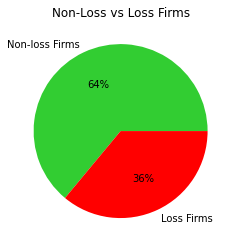

In [13]:
# 4.4 Visualisation on loss VS non-loss distribution
loss_counts = df_model["is_loss"].value_counts().sort_index()
sizes = loss_counts.values

labels = ["Non-loss Firms", "Loss Firms"]
my_colors = ["limegreen", "red"]

plt.pie(sizes, labels=labels, colors=my_colors,autopct='%1.0f%%')
plt.title("Non-Loss vs Loss Firms")
plt.show()

With the above visualisation, we noted that our transformed dataset now had roughly a 60-40 split on Non-loss to Loss-making firms respectively. This is a relatively well balanced data set, and will not require executing class balancing using SMOTE.

### Feature Engineering (Model inputs)

Having defined the modelling sample and confirmed a materially higher incidence of Non loss-making firms, we now proceed to feature engineering. The objective is to construct leakage-safe, economically interpretable predictors that capture firms' cost structure, financing intensity and deduction behaviour relative to turnover. The engineered features form the core inputs to the predictive models and allow loss outcomes to be explained in terms of underlying business characteristics rather than accounting results.

In [14]:
# Core column names
turnover = "grossturnover"
cost_sales = "cost_of_sales"
admin = "total_administrative_exp"
employment = "total_employment_exp"
finance = "total_financing_exp"
deductions = "tot_allow_deductions"

# Coverting the columns above to numeric
columns_to_fix = [turnover, cost_sales, admin, employment, finance, deductions]

for col in columns_to_fix:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

#Avoid dividing by zero to avoid errors
df_model[turnover] = df_model[turnover].replace(0, np.nan)

We proceed with creating the financial ratios

Financial ratios are essential as they give us an idea of the financial status of the firms in the sample.

In [15]:
# Calculating the ratios
df_model["cost_to_turnover"] = df_model[cost_sales] / df_model[turnover] 
df_model["admin_cost_ratio"] = df_model[admin] / df_model[turnover]
df_model["employment_cost_ratio"] = df_model[employment] / df_model[turnover]
df_model["finance_cost_ratio"] = df_model[finance] / df_model[turnover]
df_model["deductions_to_turnover"] = df_model[deductions] / df_model[turnover]

df_model["high_cost_flag"] = (df_model["cost_to_turnover"] > 0.90).astype(int)  #Structural Flags
df_model["thin_margin_flag"] = df_model["cost_to_turnover"].between(0.95, 1.05).astype(int)



# Checking the missing values & Statistical summary of the ratios
engineered = [
    "cost_to_turnover", "admin_cost_ratio",
    "employment_cost_ratio", "finance_cost_ratio",
    "deductions_to_turnover", "high_cost_flag", "thin_margin_flag"
]


display("Missing values in calculated ratios in percentage:", df_model[engineered].isnull().mean().mul(100).to_frame())
display(df_model[["cost_to_turnover", "admin_cost_ratio","employment_cost_ratio", "finance_cost_ratio","deductions_to_turnover"]].describe().round(3))

'Missing values in calculated ratios in percentage:'

,0
cost_to_turnover,0.0
admin_cost_ratio,0.0
employment_cost_ratio,0.0
finance_cost_ratio,0.0
deductions_to_turnover,0.0
high_cost_flag,0.0
thin_margin_flag,0.0


,cost_to_turnover,admin_cost_ratio,employment_cost_ratio,finance_cost_ratio,deductions_to_turnover
count,9.949100e+04,9.949100e+04,9.949100e+04,9.949100e+04,9.949100e+04
mean,2.057767e+04,2.863134e+04,2.459367e+04,3.738625e+03,5.727830e+03
std,5.368381e+06,3.690745e+06,3.515659e+06,5.939724e+05,7.533600e+05
min,-1.512180e+04,0.000000e+00,0.000000e+00,-2.110000e-01,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.920000e-01,7.000000e-03,0.000000e+00,2.000000e-03,0.000000e+00
75%,8.580000e-01,1.080000e-01,4.900000e-02,1.300000e-02,1.200000e-02
max,1.658951e+09,8.747519e+08,8.622341e+08,1.412476e+08,1.523438e+08


In [16]:
# Creating quartiles (turnover bins)
df_model["turnover_bin_q"] = pd.qcut(df_model["grossturnover"], 4, labels=["Q1", "Q2", "Q3", "Q4"]) # qcut ranks the data set in ascending order based on the turnover, and splits the arrange data into 4 equal quartiles

# Looking at loss rate by turnover quartile
# grouping the data by quartiles
loss_by_q = (df_model.groupby("turnover_bin_q")["is_loss"].mean().mul(100).round(1).to_frame("loss_rate_%"))
display(loss_by_q)

,loss_rate_%
turnover_bin_q,
Q1,41.1
Q2,41.7
Q3,33.9
Q4,27.4


Based on the distribution of firms by the quartiles, we can conclude that for the firms in Q1 (firms with low grossturnover), they reflect that 41.1% of them report losses. On the other hand, large firms (Q4), only a few of them (27.4%) reported losses in the dataset.

The distribution of loss rate by quartile is also visualised in a bar graph below.

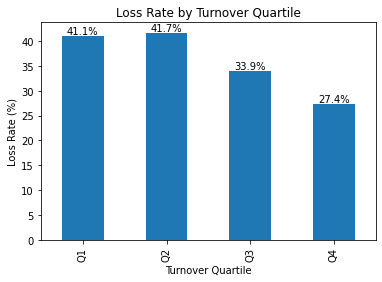

In [17]:
#Visualize the distribution of loss by turnover quartile on a bar graph
ax =loss_by_q.plot(kind='bar', legend=False)
plt.title("Loss Rate by Turnover Quartile")
plt.xlabel("Turnover Quartile")
plt.ylabel("Loss Rate (%)")

# For data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

### 6.Outlier Handling & Feature Stabilisation

The engineered features contained some extreme values, mostly driven by tiny turnover figures or data inconsistencies. To prevent these outliers from skewing our model, we applied a standard cleaning process.

We cap all ratio variables at the 1st and 99th percentiles. We also apply basic logic checks, for instance, removing negative ratios where they don't make sense. We record all these cutoff points to ensure the process is transparent and reproducible. 

In [18]:

# Outlier Handling (Winsorisation)
#   - Cap extreme ratio values to improve model stability
#   - Keep rules transparent and reproducible


RATIO_COLS = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "finance_cost_ratio",
    "deductions_to_turnover"
]

# Enforce basic economic plausibility before winsorising
df_model.loc[df_model["cost_to_turnover"] < 0, "cost_to_turnover"] = np.nan
df_model.loc[df_model["finance_cost_ratio"] < 0, "finance_cost_ratio"] = np.nan  


In [19]:
# Winsorise at 1st and 99th percentiles
caps = {}
for c in RATIO_COLS:
    lo, hi = df_model[c].quantile([0.01, 0.99]).round(3)
    caps[c] = {"p01": lo, "p99": hi}  # lo represents our lower bound of our range while hi represents the upper bound of our range
    df_model[c] = df_model[c].clip(lower=lo, upper=hi)

print("Winsorisation caps (1st and 99th percentiles):")
display(pd.DataFrame(caps).T)

Winsorisation caps (1st and 99th percentiles):


,p01,p99
cost_to_turnover,0.0,2.975
admin_cost_ratio,0.0,2.718
employment_cost_ratio,0.0,1.361
finance_cost_ratio,0.0,0.952
deductions_to_turnover,0.0,1.027


From the above results, we are capping any available outliers to fall within the range of 1st to 99th percentile.The table shows the minimum and maximum limits that were used to cap extreme values in each financial ratio during winsorisation.

In [20]:
print("\nPost-winsorisation summary (min/max/mean):")
display(df_model[RATIO_COLS].describe().round(3).T[["min", "max", "mean", "std"]])


Post-winsorisation summary (min/max/mean):


,min,max,mean,std
cost_to_turnover,0.0,2.975,0.532,0.501
admin_cost_ratio,0.0,2.718,0.134,0.357
employment_cost_ratio,0.0,1.361,0.080,0.205
finance_cost_ratio,0.0,0.952,0.034,0.123
deductions_to_turnover,0.0,1.027,0.035,0.131


After winsorisation, the minimum value of all ratios is Zero with the highest ratio of 2.975 for cost_to_turnover.This indicates that Cost_to_turnover ratio is the most volatile ratio with a mean of 0.532 and a standard deviation of 0.501.

In [21]:
# Drop minimal and explicit rows
before = df_model.shape[0]
df_model = df_model.dropna(subset=RATIO_COLS).copy()
after = df_model.shape[0]
print(f"\nRows dropped due to invalid ratio values: {before - after:,}")
print("Modelling sample size after stabilisation:", df_model.shape)


Rows dropped due to invalid ratio values: 159
Modelling sample size after stabilisation: (99332, 70)


The dataset is now clean and ready for modeling.

### 7. Saving the Final Clean Dataset

After winsorisation, we visually inspect the stabilised ratio features to confirm that extreme values have been controlled and distributions are suitable for modelling. We then freeze the modelling dataset used in all subsequent analysis to ensure full reproducibility.


The cost-to-turnover ratio has the highest average (0.532) and variability, indicating greater dispersion in overall costs relative to revenue. Administrative and employment cost ratios show moderate spread, reflecting differences in operational and staffing structures across entities. Finance costs and deductions ratios exhibit the lowest means and standard deviations, suggesting these expenses are typically minimal and more stable after outlier treatment.

8. Handling Missing Values in the Modelling Pipeline
Although the engineered features contain no missing values, the modelling pipeline explicitly includes imputation to ensure robustness and reproducibility. This safeguards the analysis against residual or future missingness and guarantees that all models are trained under consistent, production-ready preprocessing rules.

In [22]:
# Post-stabilisation diagnostics
RATIO_COLS = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "finance_cost_ratio",
    "deductions_to_turnover"
]

# Summary statistics by loss status
stats = (
    df_model
    .groupby("is_loss")[RATIO_COLS]
    .agg(["mean", "median", "std"])
)

# Rename loss indicator
stats.index = stats.index.map({0: "Non-loss", 1: "Loss"})

print("Summary statistics by loss status (post-winsorisation):")
display(stats)


Summary statistics by loss status (post-winsorisation):


cost_to_turnover                     admin_cost_ratio            \
                     mean    median       std             mean    median   
is_loss                                                                    
Non-loss         0.453607  0.527941  0.392967         0.076049  0.002779   
Loss             0.672016  0.685160  0.626187         0.237059  0.028679   

                   employment_cost_ratio                  finance_cost_ratio  \
               std                  mean median       std               mean   
is_loss                                                                        
Non-loss  0.210801              0.053018    0.0  0.142346           0.023830   
Loss      0.505999              0.126862    0.0  0.277261           0.051625   

                             deductions_to_turnover                   
            median       std                   mean median       std  
is_loss                                                               
Non-loss  0.001281  0.093651               0.019004    0.0  0.081372  
Loss      0.003453  0.161059               0.063861    0.0  0.186087

In [23]:
#Save final modeling dataset

FEATURES = [
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "finance_cost_ratio",
    "deductions_to_turnover",
    "high_cost_flag",
    "thin_margin_flag",
    "turnover_bin_q",
    "sector"
]
FINAL_COLS = FEATURES + ["is_loss"]

final_clean = df_model[FINAL_COLS].copy()

final_clean.to_csv("final_modeling_dataset.csv", index=False)
print("Final modeling dataset shape:", final_clean.shape)
print("Columns used for modeling:")
print(final_clean.columns.tolist())
print("Saved: final_clean.csv")

Final modeling dataset shape: (99332, 10)
Columns used for modeling:
['cost_to_turnover', 'admin_cost_ratio', 'employment_cost_ratio', 'finance_cost_ratio', 'deductions_to_turnover', 'high_cost_flag', 'thin_margin_flag', 'turnover_bin_q', 'sector', 'is_loss']
Saved: final_clean.csv


***8. Handling Missing Values in the Modeling Pipeline***

Although the engineered features contain no missing values, the modeling pipeline explicitly includes imputation to ensure robustness and reproducibility. This safeguards the analysis against residual or future missing values and guarantees that all models are trained under consistent, production-ready preprocessing rules.

***Preprocessing with Explicit Missing-Value Handling using Onehot encoding***

In [24]:
# Feature groups
num_vars = [                               #dealing with our numerical variables
    "cost_to_turnover",
    "admin_cost_ratio",
    "employment_cost_ratio",
    "finance_cost_ratio",
    "deductions_to_turnover",
    "high_cost_flag",
    "thin_margin_flag"
]

cat_vars = ["turnover_bin_q", "sector"]    # dealing with our Categorical variables through imputation

# Numeric pipeline                           
num_pipeline = Pipeline([                                   
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])



in the above output, "turnover_bin_q" and "sector" have been treated as categorical values where one hot encoding will be performed in the code cell below.

***Creating Pipelines for Numerical and Categorical values***

In [25]:
# Numeric pipeline  
ohe = OneHotEncoder
num_pipeline = Pipeline([                                   
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])
    

The pipeline prepares numerical features for modeling through imputation and replacing missing 
numerical values with the median.

On the other hand, the categorical pipeline prepares categorical features for modeling by imputing the
most_frequent value to the missing values.One hot encoding has also been used to convert categorical values to numeric which takes the form of (0/1).